<a href="https://colab.research.google.com/github/hapybeing/Cd274-skcm-paper/blob/main/cd274_skcm_survival_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CD274 (PD-L1) Expression and Overall Survival in TCGA-SKCM (Melanoma)

**Pre-specified protocol (locked before touching outcome data):**

- Cohort: TCGA-SKCM, PanCancer Atlas 2018 (cBioPortal `skcm_tcga_pan_can_atlas_2018`)
- Exposure: CD274 (PD-L1) mRNA expression (RNA-seq V2)
- Stratification: median split (High vs Low) — pre-specified, not an "optimal cutpoint" search
- Primary outcome: Overall survival (OS_STATUS, OS_MONTHS)
- Pre-specified analyses:
  1. Kaplan-Meier curves + log-rank test (univariate)
  2. Multivariable Cox proportional hazards model adjusting for age, sex, stage
- Significance threshold: alpha = 0.05, two-sided. Report HR + 95% CI regardless of significance.
- Rule: report whatever we find, including a null result.

Run cells top to bottom in Google Colab (needs internet access).

In [ ]:
!pip install lifelines --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.2 MB/s eta 0:00:00


In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

BASE_URL = "https://www.cbioportal.org/api"
STUDY_ID = "skcm_tcga_pan_can_atlas_2018"
GENE_SYMBOL = "CD274"  # PD-L1

## Step 1: Look up the gene

In [ ]:
resp = requests.get(f"{BASE_URL}/genes/{GENE_SYMBOL}")
resp.raise_for_status()
gene_info = resp.json()
print(gene_info)
entrez_id = gene_info["entrezGeneId"]
print(f"\n{GENE_SYMBOL} Entrez Gene ID: {entrez_id}")

{'entrezGeneId': 29126, 'hugoGeneSymbol': 'CD274', 'type': 'protein-coding'}

CD274 Entrez Gene ID: 29126


## Step 2: Find the right mRNA expression molecular profile

In [ ]:
resp = requests.get(f"{BASE_URL}/studies/{STUDY_ID}/molecular-profiles")
resp.raise_for_status()
profiles = pd.DataFrame(resp.json())
print(profiles[["molecularProfileId", "molecularAlterationType", "datatype", "name"]])

mrna_profiles = profiles[profiles["molecularAlterationType"] == "MRNA_EXPRESSION"]
print("\nmRNA expression profiles available:")
print(mrna_profiles[["molecularProfileId", "name"]])

# Prefer raw normalized RNA-seq V2 expression (not Z-scores) for a within-cohort median split
candidates = mrna_profiles[~mrna_profiles["molecularProfileId"].str.contains("zscores", case=False)]
if len(candidates) > 0:
    EXPRESSION_PROFILE_ID = candidates.iloc[0]["molecularProfileId"]
else:
    EXPRESSION_PROFILE_ID = mrna_profiles.iloc[0]["molecularProfileId"]
print(f"\nUsing expression profile: {EXPRESSION_PROFILE_ID}")

                                   molecularProfileId molecularAlterationType  \
0           skcm_tcga_pan_can_atlas_2018_armlevel_cna           GENERIC_ASSAY   
1       skcm_tcga_pan_can_atlas_2018_genetic_ancestry           GENERIC_ASSAY   
2                 skcm_tcga_pan_can_atlas_2018_gistic  COPY_NUMBER_ALTERATION   
3                skcm_tcga_pan_can_atlas_2018_log2CNA  COPY_NUMBER_ALTERATION   
4   skcm_tcga_pan_can_atlas_2018_methylation_hm27_...           GENERIC_ASSAY   
5      skcm_tcga_pan_can_atlas_2018_methylation_hm450           GENERIC_ASSAY   
6              skcm_tcga_pan_can_atlas_2018_mutations       MUTATION_EXTENDED   
7        skcm_tcga_pan_can_atlas_2018_rna_seq_v2_mrna         MRNA_EXPRESSION   
8   skcm_tcga_pan_can_atlas_2018_rna_seq_v2_mrna_m...         MRNA_EXPRESSION   
9   skcm_tcga_pan_can_atlas_2018_rna_seq_v2_mrna_m...         MRNA_EXPRESSION   
10                  skcm_tcga_pan_can_atlas_2018_rppa           PROTEIN_LEVEL   
11          skcm_tcga_pan_ca

## Step 3: Get the full-cohort sample list

In [ ]:
resp = requests.get(f"{BASE_URL}/studies/{STUDY_ID}/sample-lists")
resp.raise_for_status()
sample_lists = pd.DataFrame(resp.json())
# The error "KeyError: "['sampleCount'] not in index"" indicates that the 'sampleCount' column is not present in the DataFrame.
# This might be due to the structure of the JSON response from the API. Let's remove it from the print statement.
# If you need to inspect available columns, uncomment the line below:
# print(sample_lists.columns)
print(sample_lists[["sampleListId", "name"]])

SAMPLE_LIST_ID = f"{STUDY_ID}_all"
assert SAMPLE_LIST_ID in sample_lists["sampleListId"].values, "Check naming above and set SAMPLE_LIST_ID manually."
print(f"\nUsing sample list: {SAMPLE_LIST_ID}")

                                      sampleListId  \
0       skcm_tcga_pan_can_atlas_2018_3way_complete   
1                 skcm_tcga_pan_can_atlas_2018_all   
2                 skcm_tcga_pan_can_atlas_2018_cna   
3              skcm_tcga_pan_can_atlas_2018_cnaseq   
4             skcm_tcga_pan_can_atlas_2018_log2CNA   
5     skcm_tcga_pan_can_atlas_2018_methylation_all   
6   skcm_tcga_pan_can_atlas_2018_methylation_hm450   
7     skcm_tcga_pan_can_atlas_2018_rna_seq_v2_mrna   
8                skcm_tcga_pan_can_atlas_2018_rppa   
9           skcm_tcga_pan_can_atlas_2018_sequenced   
10                 skcm_tcga_pan_can_atlas_2018_sv   

                                     name  
0                        Complete samples  
1                             All samples  
2                   Samples with CNA data  
3      Samples with mutation and CNA data  
4      Samples with log2 copy-number data  
5           Samples with methylation data  
6   Samples with methylation data (HM450)  

## Step 4: Fetch CD274 expression for every sample

In [ ]:
payload = {"entrezGeneIds": [entrez_id], "sampleListId": SAMPLE_LIST_ID}
resp = requests.post(
    f"{BASE_URL}/molecular-profiles/{EXPRESSION_PROFILE_ID}/molecular-data/fetch",
    params={"projection": "DETAILED"},
    json=payload
)
resp.raise_for_status()
expr_records = resp.json()
print(f"Fetched {len(expr_records)} expression records")
print(expr_records[0] if expr_records else "No records returned")

expr_df = pd.DataFrame(expr_records)[["sampleId", "patientId", "value"]]
expr_df = expr_df.rename(columns={"value": "CD274_expression"})
print(expr_df.head())

Fetched 443 expression records
{'uniqueSampleKey': 'VENHQS0zTi1BOVdCLTA2OnNrY21fdGNnYV9wYW5fY2FuX2F0bGFzXzIwMTg', 'uniquePatientKey': 'VENHQS0zTi1BOVdCOnNrY21fdGNnYV9wYW5fY2FuX2F0bGFzXzIwMTg', 'entrezGeneId': 29126, 'gene': {'entrezGeneId': 29126, 'hugoGeneSymbol': 'CD274', 'type': 'protein-coding'}, 'molecularProfileId': 'skcm_tcga_pan_can_atlas_2018_rna_seq_v2_mrna', 'sampleId': 'TCGA-3N-A9WB-06', 'patientId': 'TCGA-3N-A9WB', 'studyId': 'skcm_tcga_pan_can_atlas_2018', 'value': 10.5008}
          sampleId     patientId  CD274_expression
0  TCGA-3N-A9WB-06  TCGA-3N-A9WB           10.5008
1  TCGA-3N-A9WC-06  TCGA-3N-A9WC          303.9250
2  TCGA-3N-A9WD-06  TCGA-3N-A9WD           34.0426
3  TCGA-BF-A1PU-01  TCGA-BF-A1PU            3.5714
4  TCGA-BF-A1PV-01  TCGA-BF-A1PV            5.3796


## Step 5: Fetch clinical data (survival, age, sex, stage)

In [ ]:
resp = requests.get(
    f"{BASE_URL}/studies/{STUDY_ID}/clinical-data",
    params={"clinicalDataType": "PATIENT", "projection": "SUMMARY"}
)
resp.raise_for_status()
clinical_records = resp.json()
print(f"Fetched {len(clinical_records)} clinical data points")

clinical_long = pd.DataFrame(clinical_records)[["patientId", "clinicalAttributeId", "value"]]
print(sorted(clinical_long["clinicalAttributeId"].unique().tolist()))  # inspect available attributes

clinical_df = clinical_long.pivot_table(
    index="patientId", columns="clinicalAttributeId", values="value", aggfunc="first"
).reset_index()
print(clinical_df.shape)

Fetched 16048 clinical data points
['AGE', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'AJCC_STAGING_EDITION', 'BUFFA_HYPOXIA_SCORE', 'CANCER_TYPE_ACRONYM', 'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'DSS_MONTHS', 'DSS_STATUS', 'ETHNICITY', 'FORM_COMPLETION_DATE', 'GENETIC_ANCESTRY_LABEL', 'HISTORY_NEOADJUVANT_TRTYN', 'ICD_10', 'ICD_O_3_HISTOLOGY', 'ICD_O_3_SITE', 'INFORMED_CONSENT_VERIFIED', 'IN_PANCANPATHWAYS_FREEZE', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'OS_MONTHS', 'OS_STATUS', 'OTHER_PATIENT_ID', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PERSON_NEOPLASM_CANCER_STATUS', 'PFS_MONTHS', 'PFS_STATUS', 'PRIOR_DX', 'RACE', 'RADIATION_THERAPY', 'RAGNUM_HYPOXIA_SCORE', 'SAMPLE_COUNT', 'SEX', 'SUBTYPE', 'WEIGHT', 'WINTER_HYPOXIA_SCORE']
(442, 39)


## Step 6: Build the analysis dataframe

**If any of the column names below don't appear in the attribute list printed in Step 5, fix the constants here** — TCGA PanCancer Atlas attribute IDs are fairly standard but can vary slightly.

In [ ]:
OS_STATUS_COL = "OS_STATUS"
OS_MONTHS_COL = "OS_MONTHS"
AGE_COL = "AGE"
SEX_COL = "SEX"
STAGE_COL = "AJCC_PATHOLOGIC_TUMOR_STAGE_CODE"  # inspect Step 5 output and adjust if needed

needed_cols = ["patientId", OS_STATUS_COL, OS_MONTHS_COL, AGE_COL, SEX_COL]
print("Available of needed columns:", [c for c in needed_cols if c in clinical_df.columns])

df = expr_df.merge(clinical_df, on="patientId", how="inner")
print(f"\nMerged dataframe: {df.shape[0]} patients")

df = df.dropna(subset=[OS_STATUS_COL, OS_MONTHS_COL, "CD274_expression"])
df[OS_MONTHS_COL] = pd.to_numeric(df[OS_MONTHS_COL], errors="coerce")
df = df.dropna(subset=[OS_MONTHS_COL])
df = df[df[OS_MONTHS_COL] >= 0]
print(f"After cleaning: {df.shape[0]} patients with usable expression + survival data")

Available of needed columns: ['patientId', 'OS_STATUS', 'OS_MONTHS', 'AGE', 'SEX']

Merged dataframe: 443 patients
After cleaning: 428 patients with usable expression + survival data


## Step 7: Event indicator + pre-specified median split

In [ ]:
# OS_STATUS values are typically like "0:LIVING" / "1:DECEASED"
df["event"] = df[OS_STATUS_COL].astype(str).str.startswith("1").astype(int)
print(df[OS_STATUS_COL].value_counts())

median_expr = df["CD274_expression"].median()
df["CD274_group"] = np.where(df["CD274_expression"] > median_expr, "High", "Low")
print(f"\nMedian CD274 expression: {median_expr:.3f}")
print(df["CD274_group"].value_counts())

OS_STATUS
0:LIVING      216
1:DECEASED    212
Name: count, dtype: int64

Median CD274 expression: 25.908
CD274_group
Low     214
High    214
Name: count, dtype: int64


## Step 8: Kaplan-Meier curves + log-rank test (pre-specified primary analysis #1)

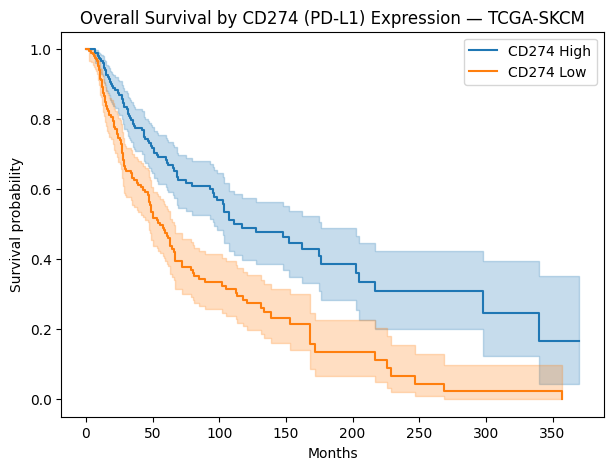


Log-rank test p-value: 0.0000


In [ ]:
high = df[df["CD274_group"] == "High"]
low = df[df["CD274_group"] == "Low"]

fig, ax = plt.subplots(figsize=(7, 5))
KaplanMeierFitter().fit(high[OS_MONTHS_COL], event_observed=high["event"], label="CD274 High").plot_survival_function(ax=ax)
KaplanMeierFitter().fit(low[OS_MONTHS_COL], event_observed=low["event"], label="CD274 Low").plot_survival_function(ax=ax)
plt.title("Overall Survival by CD274 (PD-L1) Expression — TCGA-SKCM")
plt.xlabel("Months")
plt.ylabel("Survival probability")
plt.savefig("km_curve_cd274_skcm.png", dpi=200, bbox_inches="tight")
plt.show()

result = logrank_test(high[OS_MONTHS_COL], low[OS_MONTHS_COL],
                       event_observed_A=high["event"], event_observed_B=low["event"])
print(f"\nLog-rank test p-value: {result.p_value:.4f}")

## Step 9: Multivariable Cox model (pre-specified primary analysis #2)

In [ ]:
cox_df = df.copy()
cox_df["CD274_group_bin"] = (cox_df["CD274_group"] == "High").astype(int)
cox_df[AGE_COL] = pd.to_numeric(cox_df[AGE_COL], errors="coerce")
cox_df["sex_bin"] = (cox_df[SEX_COL].astype(str).str.upper() == "MALE").astype(int)

cox_vars = ["CD274_group_bin", AGE_COL, "sex_bin"]
if STAGE_COL in cox_df.columns:
    print(cox_df[STAGE_COL].value_counts())
    # NOTE: map stage strings to an ordinal scale here once you see the categories above,
    # then add the mapped column to cox_vars.

cox_input = cox_df[[OS_MONTHS_COL, "event"] + cox_vars].dropna()
print(f"\nCox model n = {cox_input.shape[0]}")

cph = CoxPHFitter()
cph.fit(cox_input, duration_col=OS_MONTHS_COL, event_col="event")
cph.print_summary()


Cox model n = 428


<lifelines.CoxPHFitter: fitted with 428 total observations, 216 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 428
number of events observed = 212
   partial log-likelihood = -1061.13
         time fit was run = 2026-06-20 15:07:45 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
CD274_group_bin -0.67      0.51      0.14           -0.95           -0.39                0.39                0.67
AGE              0.02      1.02      0.00            0.02            0.03                1.02                1.03
sex_bin          0.10      1.10      0.15           -0.19            0.39                0.83                1.48

                 cmp to     z      p  -log2(p)
covariate                                     
CD274_group_bin    0.00 -4.76 <0.005     18.95
AGE                0.00  5.09 <0.005     21.40
sex_bin            0.00  0.67   0.50      0.99
---
Concordance = 0.64
Partial AIC = 2128.27
log-likelihood ratio test = 54.00 on 3 df
-log2(p) of ll-ratio test = 36.38

## Step 10: Sanity checks + save outputs


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.
Saved: skcm_cd274_survival_data.csv, cox_model_summary.csv, km_curve_cd274_skcm.png


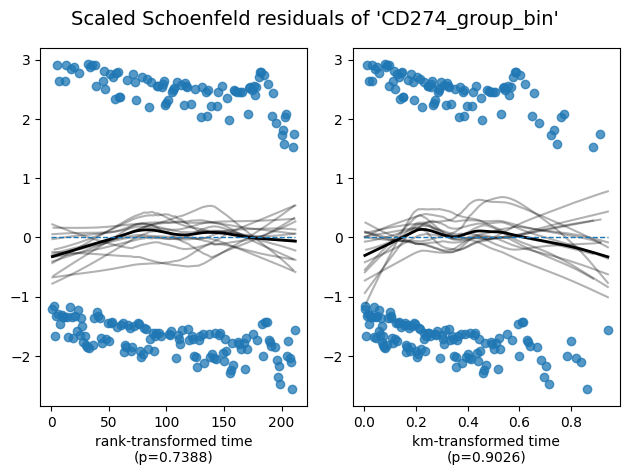

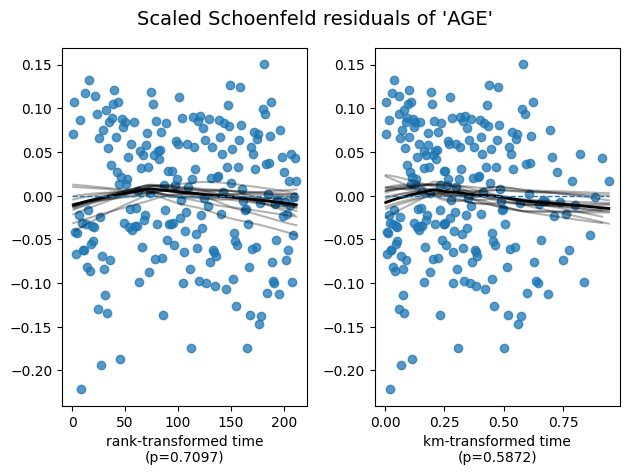

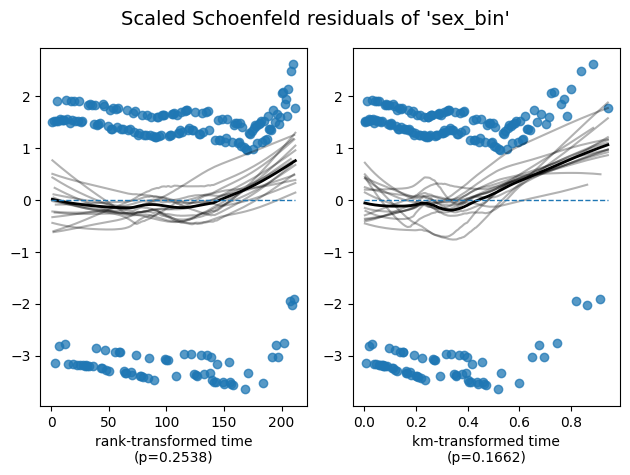

In [ ]:
cph.check_assumptions(cox_input, show_plots=True)

df.to_csv("skcm_cd274_survival_data.csv", index=False)
cph.summary.to_csv("cox_model_summary.csv")
print("Saved: skcm_cd274_survival_data.csv, cox_model_summary.csv, km_curve_cd274_skcm.png")

## Notes for write-up

- Single pre-specified hypothesis test — no multiple-comparison correction needed since no other genes were screened.
- Report the result honestly either way. A clean null result here, with a properly adjusted Cox model, is still a legitimate finding for an independent write-up.
- As a robustness check, consider re-running Step 7–9 with tertile-based grouping (another pre-specified, non-data-dredged cutpoint) and see if conclusions hold.
- If `cph.check_assumptions` flags a proportional-hazards violation for any covariate, note it explicitly in Methods/Limitations rather than ignoring it.